# Dialect Identification (7-way) — Arabic

7-way classification of Arabic dialect/variety. MARBERT is used as the stronger baseline since it is pretrained specifically on dialectal Arabic (Twitter-sourced), making it the right comparison point here.

**Pipeline in this notebook**
1. Load & clean data
2. Baseline A: TF-IDF + Logistic Regression / Linear SVM
3. Baseline B (stronger): fine-tuned `UBC-NLP/MARBERT`
4. Zero-shot prompting with an open-source Arabic LLM (Jais), no fine-tuning
5. Side-by-side comparison table
6. Qualitative error analysis (auto-detects the most-confused label pair)

**Runtime:** Colab, GPU runtime recommended (`Runtime > Change runtime type > GPU`).
Steps 2 runs fine on CPU; steps 3–4 need a GPU.


In [ ]:
# ---------------------------------------------------------------
# 0. Install dependencies (versions pinned for reproducibility)
# ---------------------------------------------------------------
!pip -q install -U "transformers==4.44.2" "accelerate==0.34.2" "datasets==2.21.0" \
    "huggingface_hub==0.24.6" sentencepiece einops


In [1]:
import os, re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## 1. Configuration

Edit the constants below to match your dataset and task. Everything downstream
references these, so this is the only cell you should need to touch to adapt
the notebook.


In [23]:
# --- Task config -------------------------------------------------
TASK_NAME = "dialect_identification"

# Labels must EXACTLY match the strings used in your CSV's `label` column,
# in the order you want them to appear in tables / confusion matrices.
LABELS = ["Saudi", "Yemen", "Morocco", "Algeria", "Libya", "Tunisia"]
NUM_LABELS = 6
label2id = {lab: i for i, lab in enumerate(LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

# --- Data ----------------------------------------------------------------
# You have:
#   - One CSV with both train and val data (distinguished by a "split" column)
#   - One separate CSV with test data
TRAIN_VAL_DATA_PATH = "Data/training/joke_dialect_detection(training).csv"
TEST_DATA_PATH = "Data/testing/joke_dialect_detection(testing).csv"

# --- Models ----------------------------------------------------------------
TRANSFORMER_MODEL = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
# TRANSFORMER_MODEL = "UBC-NLP/MARBERTv2"
# Alternative: "CAMeL-Lab/bert-base-arabic-camelbert-mix" (CAMeLBERT)

JAIS_MODEL_NAME = "inceptionai/jais-family-590m-chat"
# Bump to "inceptionai/jais-family-2p7b-chat" or "inceptionai/jais-family-6p7b-chat" if you have an A100 — larger Jais checkpoints give a meaningfully stronger zero-shot baseline.

# Set to an int (e.g. 200) to run zero-shot on a subsample for speed,
# or None to run on the full test set.
ZERO_SHOT_SAMPLE_SIZE = 200



## 2. Load data

Two common ways to get your CSV into Colab:

```python
# Option A: upload directly
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Option B: mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/path/to/your_file.csv"
```

**Important:** the placeholder `LABELS` list (`MSA/EGY/GLF/LEV/IRQ/MAG/YEM`) is a generic guess at common 7-way Arabic dialect schemes (e.g. similar to NADI/MADAR-style label sets). Replace it with the exact label strings your dataset uses, in the config cell above, before running anything else — everything downstream (LABEL_AR dict included) keys off this list.


In [3]:
df = pd.read_csv(DATA_PATH)
assert "text" in df.columns and "label" in df.columns, (
    "Expected columns 'text' and 'label' in the CSV. Got: " + str(list(df.columns))
)

df["text"] = df["text"].astype(str)
unknown_labels = set(df["label"].unique()) - set(LABELS)
assert not unknown_labels, f"Found labels not in LABELS config: {unknown_labels}"

print("Rows:", len(df))
print(df["label"].value_counts())
df.head()


NameError: name 'DATA_PATH' is not defined

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG
# -----------------------------
LABELS = ["Saudi", "Yemen", "Morocco", "Algeria", "Libya", "Tunisia"]
label2id = {label: i for i, label in enumerate(LABELS)}


# -----------------------------
# LOADER FUNCTION
# -----------------------------
def load_csv(path, name):
    df = pd.read_csv(path)
    df.dropna(subset = ['label'], inplace=True)
    df = df[~df["label"].isin(["Qatar", "Sudan", "Syria", "Egypt"])]
    # Check required columns
    assert "text" in df.columns and "label" in df.columns, (
        f"{name}: Expected columns 'text' and 'label'. Got: {list(df.columns)}"
    )

    # Ensure text is string
    df["text"] = df["text"].astype(str)

    # Validate labels
    unknown_labels = set(df["label"].unique()) - set(LABELS)
    assert not unknown_labels, (
        f"{name}: Found labels not in LABELS config: {unknown_labels}"
    )

    # Map labels to IDs
    df["label_id"] = df["label"].map(label2id)

    return df.reset_index(drop=True)

# -----------------------------
# LOAD TRAIN/VAL
# -----------------------------
train_val_df = load_csv(TRAIN_VAL_DATA_PATH, "TRAIN_VAL")


# If split column exists → use it
if "split" in train_val_df.columns:
    train_df = train_val_df[train_val_df["split"] == "train"].reset_index(drop=True)
    val_df = train_val_df[train_val_df["split"] == "val"].reset_index(drop=True)

# Otherwise → create split
else:
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.1,
        random_state=42,
        stratify=train_val_df["label"]
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

# -----------------------------
# LOAD TEST
# -----------------------------
test_df = load_csv(TEST_DATA_PATH, "TEST")

# -----------------------------
# PRINT STATS
# -----------------------------
print("Dataset sizes:")
print(f"  train: {len(train_df)}")
print(f"  val:   {len(val_df)}")
print(f"  test:  {len(test_df)}")

print("\nLabel distribution:")

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name}:")
    print(df["label"].value_counts().sort_index())

Dataset sizes:
  train: 1737
  val:   194
  test:  388

Label distribution:

train:
label
Algeria    168
Libya      317
Morocco    413
Saudi      322
Tunisia    276
Yemen      241
Name: count, dtype: int64

val:
label
Algeria    19
Libya      35
Morocco    46
Saudi      36
Tunisia    31
Yemen      27
Name: count, dtype: int64

test:
label
Algeria    70
Libya      60
Morocco    70
Saudi      92
Tunisia    19
Yemen      77
Name: count, dtype: int64


## 3. Text cleaning

Light, reversible normalization for Arabic: strips diacritics/tatweel,
normalizes alef/yaa variants, collapses whitespace, and removes characters
outside the Arabic block + basic punctuation + Latin/digits (keeps hashtags
and numbers, drops most emoji/noise).

`normalize_taa_marbuta` is exposed as a flag: collapsing ة→ه can erase a
genuine dialectal/orthographic signal, so it defaults to
**False** for this task — change it if your error analysis
suggests otherwise.


In [25]:
ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]")

def normalize_arabic(text: str, normalize_taa_marbuta: bool = True) -> str:
    if not isinstance(text, str):
        return ""
    text = ARABIC_DIACRITICS.sub("", text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    if normalize_taa_marbuta:
        text = re.sub(r"ة", "ه", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"[^\u0600-\u06FF0-9a-zA-Z\s.,!?؟،#]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning to all splits
for split_df in [train_df, val_df, test_df]:
    split_df["clean_text"] = split_df["text"].apply(normalize_arabic)
    # Remove rows with empty cleaned text
    keep_idx = split_df["clean_text"].str.len() > 0
    split_df.drop(split_df[~keep_idx].index, inplace=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("After text cleaning:")
print(f"  train: {len(train_df)}")
print(f"  val:   {len(val_df)}")
print(f"  test:  {len(test_df)}")

# Show samples from each split
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name} sample:")
    display(df[["text", "clean_text", "label"]].head(2))


After text cleaning:
  train: 1737
  val:   194
  test:  388

train sample:


,text,clean_text,label
0,اعلنوااا حظر التجول بالقصيم طلعوااا كلهم يشوفو...,اعلنوااا حظر التجول بالقصيم طلعوااا كلهم يشوفو...,Saudi
1,فما واحد سكران شد يضرب في راسو عالحيط ويقول يا...,فما واحد سكران شد يضرب في راسو عالحيط ويقول يا...,Tunisia



val sample:


,text,clean_text,label
0,في إحدى الشركات اتصل موظف على تليفون مديره بال...,في احدي الشركات اتصل موظف علي تليفون مديره بال...,Libya
1,محشش يشاهد مباراة لريال مدريد و سمع المذيع فاو...,محشش يشاهد مباراه لريال مدريد و سمع المذيع فاو...,Saudi



test sample:


,text,clean_text,label
0,هدا واحد الفار فاق مقطوع في رمضان او هو يعربط ...,هدا واحد الفار فاق مقطوع في رمضان او هو يعربط ...,Morocco
1,كاليك هدا فار مشا يخطب فارة مش عند واليدها قال...,كاليك هدا فار مشا يخطب فاره مش عند واليدها قال...,Morocco


In [26]:
print("=== Final dataset summary ===")
print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

print("\nLabel distributions:")
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name}:")
    for label in LABELS:
        count = (df["label"] == label).sum()
        pct = 100.0 * count / len(df)
        print(f"  {label:15s}: {count:4d} ({pct:5.1f}%)")


=== Final dataset summary ===
Train size: 1737
Val size:   194
Test size:  388

Label distributions:

train:
  Saudi          :  322 ( 18.5%)
  Yemen          :  241 ( 13.9%)
  Morocco        :  413 ( 23.8%)
  Algeria        :  168 (  9.7%)
  Libya          :  317 ( 18.2%)
  Tunisia        :  276 ( 15.9%)

val:
  Saudi          :   36 ( 18.6%)
  Yemen          :   27 ( 13.9%)
  Morocco        :   46 ( 23.7%)
  Algeria        :   19 (  9.8%)
  Libya          :   35 ( 18.0%)
  Tunisia        :   31 ( 16.0%)

test:
  Saudi          :   92 ( 23.7%)
  Yemen          :   77 ( 19.8%)
  Morocco        :   70 ( 18.0%)
  Algeria        :   70 ( 18.0%)
  Libya          :   60 ( 15.5%)
  Tunisia        :   19 (  4.9%)


In [27]:
from sklearn.utils import resample
import pandas as pd

def upsample_df(df):
    max_size = df["label"].value_counts().max()

    dfs = []
    for label in df["label"].unique():
        df_label = df[df["label"] == label]

        df_upsampled = resample(
            df_label,
            replace=True,
            n_samples=max_size,
            random_state=42
        )
        dfs.append(df_upsampled)

    return pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

In [28]:
train_df = upsample_df(train_df)
val_df = upsample_df(val_df)
print("\nLabel distributions:")
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name}:")
    for label in LABELS:
        count = (df["label"] == label).sum()
        pct = 100.0 * count / len(df)
        print(f"  {label:15s}: {count:4d} ({pct:5.1f}%)")


Label distributions:

train:
  Saudi          :  413 ( 16.7%)
  Yemen          :  413 ( 16.7%)
  Morocco        :  413 ( 16.7%)
  Algeria        :  413 ( 16.7%)
  Libya          :  413 ( 16.7%)
  Tunisia        :  413 ( 16.7%)

val:
  Saudi          :   46 ( 16.7%)
  Yemen          :   46 ( 16.7%)
  Morocco        :   46 ( 16.7%)
  Algeria        :   46 ( 16.7%)
  Libya          :   46 ( 16.7%)
  Tunisia        :   46 ( 16.7%)

test:
  Saudi          :   92 ( 23.7%)
  Yemen          :   77 ( 19.8%)
  Morocco        :   70 ( 18.0%)
  Algeria        :   70 ( 18.0%)
  Libya          :   60 ( 15.5%)
  Tunisia        :   19 (  4.9%)


## 4. Train / validation / test split

Uses an existing `split` column if your CSV has one; otherwise creates a
stratified 70/15/15 split.


In [29]:
# if "split" in df.columns:
#     train_df = df[df["split"] == "train"].reset_index(drop=True)
#     val_df   = df[df["split"] == "val"].reset_index(drop=True)
#     test_df  = df[df["split"] == "test"].reset_index(drop=True)
# else:
#     train_df, rest_df = train_test_split(
#         df, test_size=0.30, stratify=df["label"], random_state=SEED
#     )
#     val_df, test_df = train_test_split(
#         rest_df, test_size=0.50, stratify=rest_df["label"], random_state=SEED
#     )
#     train_df = train_df.reset_index(drop=True)
#     val_df = val_df.reset_index(drop=True)
#     test_df = test_df.reset_index(drop=True)

# print("train:", len(train_df), " val:", len(val_df), " test:", len(test_df))


In [30]:
# Shared evaluation helper used by every model in this notebook
def evaluate_predictions(y_true, y_pred, model_name, labels=LABELS, plot=True):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0, labels=labels
    )
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    if plot:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure(figsize=(1.2 * len(labels) + 2, 1.0 * len(labels) + 2))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix — {model_name}")
        plt.tight_layout(); plt.show()

    return {"model": model_name, "accuracy": acc, "macro_f1": f1,
            "macro_precision": p, "macro_recall": r}

results = []  # collects metric dicts from every model below


## 5. Baseline A — TF-IDF + Logistic Regression / Linear SVM


Best C: {'clf__C': 3.0}
=== TF-IDF + LogisticRegression ===
              precision    recall  f1-score   support

       Saudi       0.65      0.60      0.62        92
       Yemen       0.58      0.56      0.57        77
     Morocco       0.92      0.79      0.85        70
     Algeria       0.93      0.79      0.85        70
       Libya       0.62      0.85      0.72        60
     Tunisia       0.66      1.00      0.79        19

    accuracy                           0.72       388
   macro avg       0.73      0.76      0.73       388
weighted avg       0.73      0.72      0.72       388



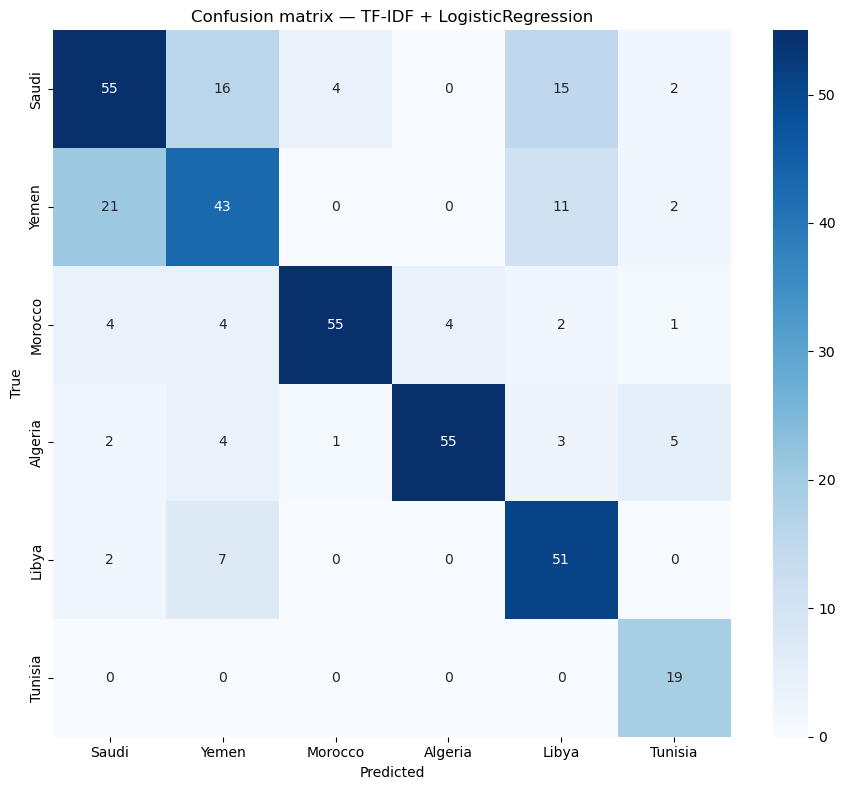

[[55  3  1  2  5  4]
 [ 0 51  0  2  0  7]
 [ 4  2 55  4  1  4]
 [ 0 15  4 55  2 16]
 [ 0  0  0  0 19  0]
 [ 0 11  0 21  2 43]]


In [31]:
tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=30000, sublinear_tf=True, min_df=2)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

param_grid = {"clf__C": [0.1, 1.0, 3.0, 10.0]}
gs_logreg = GridSearchCV(tfidf_logreg, param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
gs_logreg.fit(train_df["clean_text"], train_df["label"])
print("Best C:", gs_logreg.best_params_)

logreg_preds = gs_logreg.predict(test_df["clean_text"])
results.append(evaluate_predictions(test_df["label"], logreg_preds, "TF-IDF + LogisticRegression"))
cm = confusion_matrix(test_df["label"], logreg_preds)
print(cm)

Best C: {'clf__C': 1.0}
=== TF-IDF + LinearSVC ===
              precision    recall  f1-score   support

       Saudi       0.66      0.64      0.65        92
       Yemen       0.55      0.53      0.54        77
     Morocco       0.93      0.79      0.85        70
     Algeria       0.90      0.80      0.85        70
       Libya       0.64      0.77      0.70        60
     Tunisia       0.61      1.00      0.76        19

    accuracy                           0.71       388
   macro avg       0.72      0.75      0.72       388
weighted avg       0.73      0.71      0.71       388



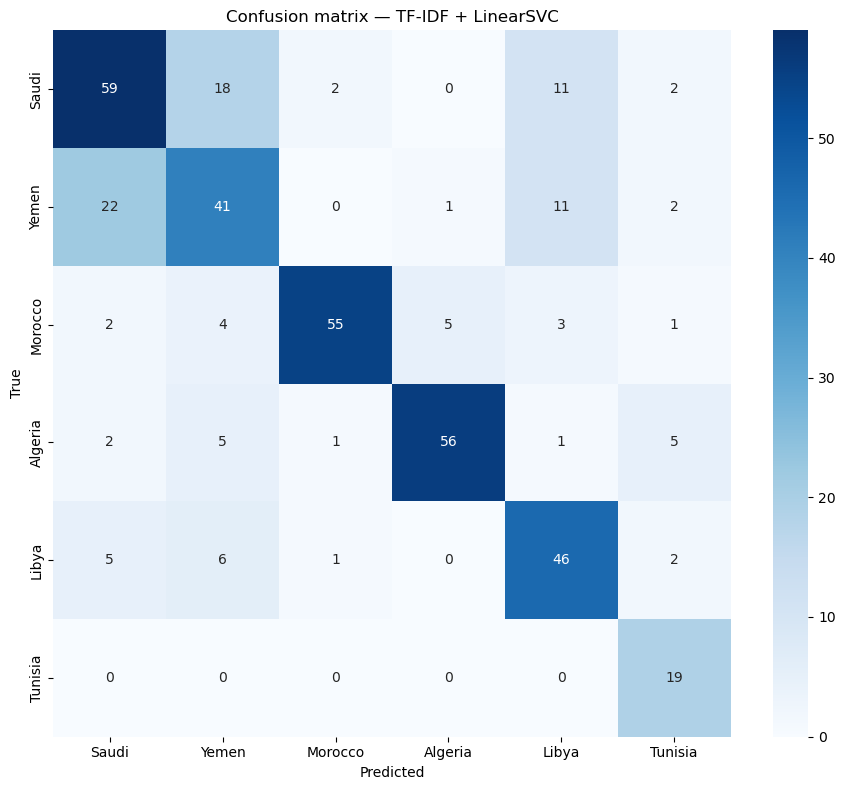

[[56  1  1  2  5  5]
 [ 0 46  1  5  2  6]
 [ 5  3 55  2  1  4]
 [ 0 11  2 59  2 18]
 [ 0  0  0  0 19  0]
 [ 1 11  0 22  2 41]]


In [32]:
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=30000, sublinear_tf=True, min_df=2)),
    ("clf", LinearSVC(class_weight="balanced")),
])

gs_svm = GridSearchCV(tfidf_svm, {"clf__C": [0.1, 1.0, 3.0, 10.0]}, cv=3, scoring="f1_macro", n_jobs=-1)
gs_svm.fit(train_df["clean_text"], train_df["label"])
print("Best C:", gs_svm.best_params_)

svm_preds = gs_svm.predict(test_df["clean_text"])
results.append(evaluate_predictions(test_df["label"], svm_preds, "TF-IDF + LinearSVC"))
cm = confusion_matrix(test_df["label"], svm_preds)
print(cm)

## 6. Baseline B (stronger) — fine-tuned `UBC-NLP/MARBERT`


In [33]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

def tokenize_fn(batch):
    return tokenizer(batch["clean_text"], truncation=True, max_length=128)

cols_keep = ["clean_text", "label_id"]
train_ds = Dataset.from_pandas(train_df[cols_keep].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[cols_keep].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[cols_keep].reset_index(drop=True))

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.rename_column("label_id", "labels")
val_ds   = val_ds.rename_column("label_id", "labels")
test_ds  = test_ds.rename_column("label_id", "labels")

keep_cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=keep_cols)
val_ds.set_format(type="torch", columns=keep_cols)
test_ds.set_format(type="torch", columns=keep_cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/2478 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

In [34]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_f1": f1, "macro_precision": p, "macro_recall": r}

model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_MODEL, num_labels=NUM_LABELS)

training_args = TrainingArguments(
    output_dir=f"./{TASK_NAME}_finetuned",
    eval_strategy="epoch",   # transformers>=4.46 renamed this to eval_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.596776,0.696551,0.760870,0.762079,0.767438,0.760870
2,0.238634,1.050243,0.717391,0.691005,0.732624,0.717391
3,0.085404,0.973449,0.789855,0.792876,0.804671,0.789855
4,0.040191,1.144183,0.786232,0.784563,0.789454,0.786232
5,0.033344,1.339295,0.778986,0.768745,0.780197,0.778986
6,0.010141,1.403680,0.775362,0.769299,0.780493,0.775362
7,0.011969,1.391889,0.771739,0.764621,0.768597,0.771739
8,0.014539,1.452758,0.793478,0.785019,0.793435,0.793478
9,0.027461,1.445765,0.768116,0.761710,0.765888,0.768116
10,0.017190,1.481071,0.782609,0.774835,0.781969,0.782609


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1550, training_loss=0.1526139448246648, metrics={'train_runtime': 52.9294, 'train_samples_per_second': 468.171, 'train_steps_per_second': 29.284, 'total_flos': 1353034499415768.0, 'train_loss': 0.1526139448246648, 'epoch': 10.0})

=== Fine-tuned bert-base-arabic-camelbert-mix ===
              precision    recall  f1-score   support

       Saudi       0.82      0.67      0.74        92
       Yemen       0.67      0.62      0.64        77
     Morocco       1.00      0.70      0.82        70
     Algeria       0.87      0.76      0.81        70
       Libya       0.71      0.82      0.76        60
     Tunisia       0.31      1.00      0.47        19

    accuracy                           0.72       388
   macro avg       0.73      0.76      0.71       388
weighted avg       0.79      0.72      0.74       388



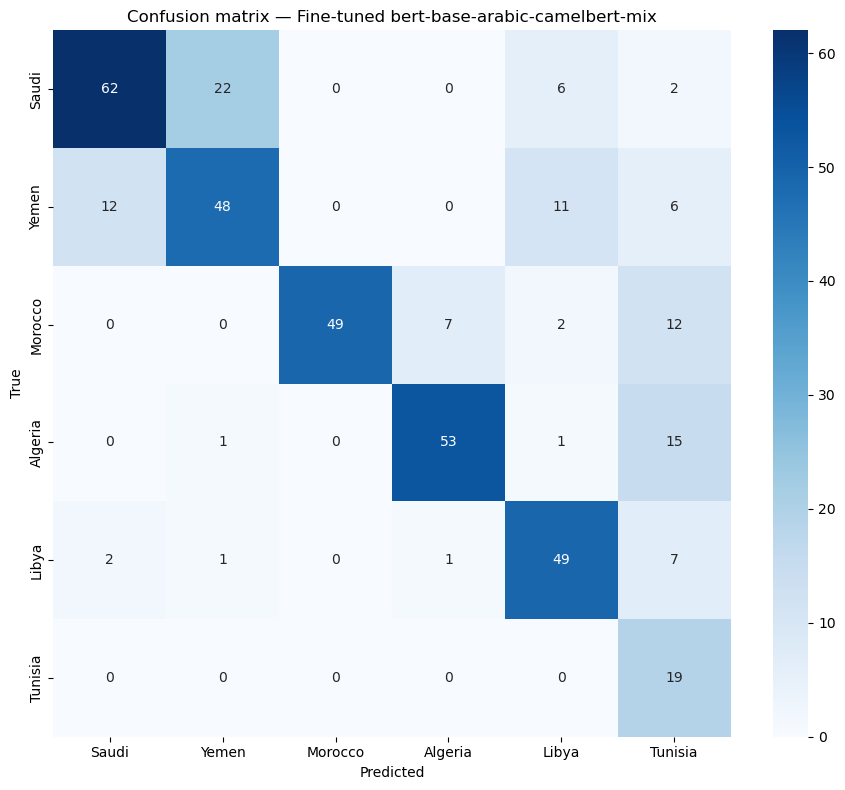

[[55  3  1  2  5  4]
 [ 0 51  0  2  0  7]
 [ 4  2 55  4  1  4]
 [ 0 15  4 55  2 16]
 [ 0  0  0  0 19  0]
 [ 0 11  0 21  2 43]]


In [35]:
test_output = trainer.predict(test_ds)
transformer_preds_id = np.argmax(test_output.predictions, axis=-1)
transformer_preds = [id2label[i] for i in transformer_preds_id]

results.append(evaluate_predictions(test_df["label"], transformer_preds,
                                     f"Fine-tuned {TRANSFORMER_MODEL.split('/')[-1]}"))

# Keep these for the error-analysis section later
test_df["pred_transformer"] = transformer_preds
cm = confusion_matrix(test_df["label"], logreg_preds)
print(cm)

## 7. Zero-shot prompting with Jais (no fine-tuning)

We score each candidate label as a *continuation* of the prompt and pick the
one the model assigns the highest average log-probability to. This avoids
brittle free-text parsing and is the standard "rank classification" approach
for zero-shot evaluation of causal LMs.

> ⚠️ The prompt template below follows Inception AI's published Jais-chat
> format. Double-check it against the model card for whichever `JAIS_MODEL_NAME`
> checkpoint you select — chat templates occasionally differ across Jais
> releases (e.g. `jais-13b-chat-v1` vs the newer `jais-family-*-chat` models).


In [ ]:
from transformers import AutoModelForCausalLM

jais_tokenizer = AutoTokenizer.from_pretrained(JAIS_MODEL_NAME)
jais_model = AutoModelForCausalLM.from_pretrained(
    JAIS_MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
jais_model.eval()


In [ ]:
SYSTEM_PROMPT_AR = "أنت مساعد متخصص في تصنيف اللهجات العربية. مهمتك تصنيف النص إلى لهجة واحدة فقط من القائمة المعطاة، بدون أي شرح إضافي."
INSTRUCTION_AR = "ما هي اللهجة العربية لهذا النص؟ اختر إجابة واحدة فقط من: الفصحى، المصرية، الخليجية، الشامية، العراقية، المغاربية، اليمنية."
LABEL_AR = {"MSA": "الفصحى", "EGY": "المصرية", "GLF": "الخليجية", "LEV": "الشامية", "IRQ": "العراقية", "MAG": "المغاربية", "YEM": "اليمنية"}  # canonical label -> natural Arabic phrase used as the scored completion

def build_prompt(text: str) -> str:
    user_turn = f"[|Human|] {INSTRUCTION_AR}\nالنص: \"{text}\"\nالتصنيف:"
    return f"### Instruction: {SYSTEM_PROMPT_AR}\n### Input: {user_turn}\n### Response: [|AI|] "

print(build_prompt("نص تجريبي هنا"))


In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def score_candidate(prompt: str, candidate: str) -> float:
    """Average per-token log-prob the model assigns to `candidate`
    immediately following `prompt`. Higher = more likely completion."""
    full_text = prompt + candidate
    prompt_ids = jais_tokenizer(prompt, return_tensors="pt").input_ids.to(jais_model.device)
    full_ids = jais_tokenizer(full_text, return_tensors="pt").input_ids.to(jais_model.device)

    outputs = jais_model(full_ids)
    logits = outputs.logits[0]

    n_prompt_tokens = prompt_ids.shape[-1]
    target_ids = full_ids[0, n_prompt_tokens:]
    relevant_logits = logits[n_prompt_tokens - 1: -1, :]
    log_probs = F.log_softmax(relevant_logits.float(), dim=-1)
    token_log_probs = log_probs[torch.arange(len(target_ids)), target_ids]
    return token_log_probs.mean().item()


def zero_shot_classify(text: str):
    prompt = build_prompt(text)
    scores = [score_candidate(prompt, " " + LABEL_AR[lab]) for lab in LABELS]
    best_idx = int(np.argmax(scores))
    return LABELS[best_idx], scores


In [ ]:
eval_pool = test_df.sample(
    n=min(ZERO_SHOT_SAMPLE_SIZE, len(test_df)) if ZERO_SHOT_SAMPLE_SIZE else len(test_df),
    random_state=SEED,
).reset_index(drop=True)

zero_shot_preds = []
for txt in tqdm(eval_pool["clean_text"], desc="Zero-shot scoring"):
    pred, _ = zero_shot_classify(txt)
    zero_shot_preds.append(pred)

eval_pool["pred_zero_shot"] = zero_shot_preds
results.append(evaluate_predictions(eval_pool["label"], zero_shot_preds,
                                     f"Zero-shot {JAIS_MODEL_NAME.split('/')[-1]}"))


### (Optional) Free-text generation, for qualitative inspection

The log-likelihood scoring above is the metric we report. This cell is just
useful if you want to see what the model *says* in its own words for a few
examples — handy for the paper's qualitative section.


In [ ]:
@torch.no_grad()
def generate_explanation(text: str, max_new_tokens: int = 40) -> str:
    prompt = build_prompt(text)
    input_ids = jais_tokenizer(prompt, return_tensors="pt").input_ids.to(jais_model.device)
    gen_ids = jais_model.generate(
        input_ids, max_new_tokens=max_new_tokens, do_sample=False,
        repetition_penalty=1.2, pad_token_id=jais_tokenizer.eos_token_id,
    )
    full = jais_tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    return full[len(jais_tokenizer.decode(input_ids[0], skip_special_tokens=True)):].strip()

for txt in eval_pool["clean_text"].head(3):
    print("TEXT:", txt)
    print("MODEL SAYS:", generate_explanation(txt))
    print("---")


## 8. Comparison table


In [ ]:
results_df = pd.DataFrame(results).set_index("model")
results_df = results_df.round(3)
display(results_df)

ax = results_df[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(8, 4))
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Dialect Identification (7-way) — Arabic — model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

results_df.to_csv(f"{TASK_NAME}_results.csv")


## 9. Error analysis

Expect the most confusion between geographically/linguistically close varieties (e.g. Gulf vs Iraqi, or Levantine vs MSA in more formal register text) rather than between distant ones (e.g. Maghrebi vs Gulf).

The cell below auto-detects the most-confused label pair from the **fine-tuned
transformer's** test predictions (usually the strongest model, so its
remaining mistakes are the most informative) and prints a few concrete
examples for both confusion directions — good source material for a
qualitative error-analysis subsection.


In [ ]:
def most_confused_pair(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    np.fill_diagonal(cm, 0)
    i, j = np.unravel_index(np.argmax(cm), cm.shape)
    return labels[i], labels[j], int(cm[i, j])

true_a, pred_b, n_confused = most_confused_pair(test_df["label"], test_df["pred_transformer"], LABELS)
print(f"Most common confusion: true='{true_a}' predicted as '{pred_b}' ({n_confused} cases)")

def show_examples(df_, true_label, pred_label, pred_col="pred_transformer", n=8):
    subset = df_[(df_["label"] == true_label) & (df_[pred_col] == pred_label)]
    cols = ["text", "label", pred_col]
    return subset[cols].head(n)

print(f"\nExamples: true={true_a} -> predicted={pred_b}")
display(show_examples(test_df, true_a, pred_b))

print(f"\nExamples (reverse direction): true={pred_b} -> predicted={true_a}")
display(show_examples(test_df, pred_b, true_a))


## 10. Notes for the paper

- Report the comparison table above as the main results table for this task.
- Use the auto-detected confusion pair + printed examples as concrete
  evidence in your qualitative error-analysis section.
- The zero-shot Jais numbers are a baseline-for-comparison, not a competitive
  system — expect it to trail both TF-IDF and the fine-tuned transformer
  unless the chosen Jais checkpoint is large; that gap is itself worth
  reporting as motivation for fine-tuning / future work.
